<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 7.2
### **Date: 04/24/2026** 

---

**References:**

House prices - advanced regression techniques. (n.d.). Kaggle. https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data?select=train.csv

Mushroom classification. (2016, December 1). https://www.kaggle.com/datasets/uciml/mushroom-classification

</div>

## **Initial Setup:**

In [34]:
# Libraries
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# Visualization settings
ROYAL_BLUE = '#4169E1'
PURPLE = '#4B0082'
FOREST = '#228B22'
PALETTE = [ROYAL_BLUE, PURPLE, FOREST, '#E07B39', '#888888']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.prop_cycle': plt.cycler('color', PALETTE),
})

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Load Datasets
housing_df = pd.read_csv('train.csv')
mushroom_df = pd.read_csv('mushrooms.csv')

print('✅ Libraries loaded — warnings suppressed')
print(
    f'🏠 Housing dataset  : {housing_df.shape[0]:,} rows × {housing_df.shape[1]} columns')
print(
    f'🍄 Mushroom dataset : {mushroom_df.shape[0]:,} rows × {mushroom_df.shape[1]} columns')

✅ Libraries loaded — warnings suppressed
🏠 Housing dataset  : 1,460 rows × 81 columns
🍄 Mushroom dataset : 8,124 rows × 23 columns


---
## Part 1 — PCA and Variance Threshold in a Linear Regression

In [35]:
# Inspect the housing dataframe
def inspect_dataframe(df, name='DataFrame'):
    """Print shape, dtype summary, and missing value count for a given dataframe."""
    print(f'📋 {name}')
    print(
        f'   Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns')
    n_numeric = df.select_dtypes(include='number').shape[1]
    n_object = df.select_dtypes(include='object').shape[1]
    print(f'   Numeric columns  : {n_numeric}')
    print(f'   Categorical cols : {n_object}')
    print(f'   Total missing    : {df.isnull().sum().sum():,}')
    return df.head(3)


inspect_dataframe(housing_df, 'Housing (train.csv)')

📋 Housing (train.csv)
   Shape            : 1,460 rows × 81 columns
   Numeric columns  : 38
   Categorical cols : 43
   Total missing    : 7,829


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [36]:
# Drop 'Id' and columns missing more than 40% of values
def drop_high_missing(df, threshold=0.4):
    """Drop Id column and any feature with a missing rate above threshold."""
    df = df.drop(columns=['Id'])
    missing_rate = df.isnull().mean()
    cols_to_drop = missing_rate[missing_rate > threshold].index.tolist()
    print(
        f'🗑️  Columns dropped (>{threshold*100:.0f}% missing): {cols_to_drop}')
    df = df.drop(columns=cols_to_drop)
    print(
        f'   Shape after drop : {df.shape[0]:,} rows × {df.shape[1]} columns')
    return df


housing_clean = drop_high_missing(housing_df.copy())

🗑️  Columns dropped (>40% missing): ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
   Shape after drop : 1,460 rows × 74 columns


In [37]:
# Median imputation (numeric), mode imputation (categorical)
def impute_columns(df):
    """Fill numeric NaNs with column median; fill categorical NaNs with column mode."""
    num_cols = df.select_dtypes(include='number').columns
    cat_cols = df.select_dtypes(include='object').columns

    num_missing = df[num_cols].isnull().sum().sum()
    cat_missing = df[cat_cols].isnull().sum().sum()

    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    print(f'🔢 Numeric  : {num_missing:,} values imputed with column median')
    print(f'🔤 Categorical : {cat_missing:,} values imputed with column mode')
    print(
        f'✅ Imputation complete — remaining missing values: {df.isnull().sum().sum()}')
    return df


housing_clean = impute_columns(housing_clean)

🔢 Numeric  : 348 values imputed with column median
🔤 Categorical : 512 values imputed with column mode
✅ Imputation complete — remaining missing values: 0


In [38]:
# One-hot encode all categorical columns
def encode_categoricals(df):
    """One-hot encode all object-dtype columns, dropping the first level to avoid multicollinearity."""
    before = df.shape[1]
    df = pd.get_dummies(df, drop_first=True)
    print(f'🔢 Encoding complete')
    print(f'   Before : {before} columns')
    print(f'   After  : {df.shape[1]} columns')
    return df


housing_encoded = encode_categoricals(housing_clean.copy())

🔢 Encoding complete
   Before : 74 columns
   After  : 230 columns


In [39]:
# Split features and target into train and test sets
X = housing_encoded.drop(columns=['SalePrice'])
y = housing_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'✂️  Target  : SalePrice')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}')
print(f'   y_test  : {y_test.shape}')

✂️  Target  : SalePrice
   X_train : (1168, 229)
   X_test  : (292, 229)
   y_train : (1168,)
   y_test  : (292,)


In [40]:
# Baseline linear regression — R² and RMSE on test set
def evaluate_regression(X_tr, X_te, y_tr, y_te, label='Model'):
    """Fit a linear regression on training data and report R² and RMSE on the test set."""
    lr = LinearRegression()
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    print(f'📊 {label}')
    print(f'   R²   : {r2:.4f}')
    print(f'   RMSE : ${rmse:,.2f}')
    return r2, rmse


r2_base, rmse_base = evaluate_regression(
    X_train, X_test, y_train, y_test, 'Baseline (all 229 features)'
)

📊 Baseline (all 229 features)
   R²   : 0.6478
   RMSE : $51,973.14


In [41]:
# Scale first, then fit PCA on train, transform test
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(
    X_train)   # fit + transform on train only
X_test_scaled_pca = scaler_pca.transform(
    X_test)        # transform only — do NOT fit

pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
# fit + transform on train only
X_train_pca = pca.fit_transform(X_train_scaled_pca)
# transform only — do NOT fit
X_test_pca = pca.transform(X_test_scaled_pca)

print(f'🔵 StandardScaler applied, then PCA retaining 90% of variance')
print(f'   Original features   : {X_train.shape[1]}')
print(f'   PCA components kept : {pca.n_components_}')
print(f'   X_train_pca shape   : {X_train_pca.shape}')
print(f'   X_test_pca shape    : {X_test_pca.shape}')

🔵 StandardScaler applied, then PCA retaining 90% of variance
   Original features   : 229
   PCA components kept : 127
   X_train_pca shape   : (1168, 127)
   X_test_pca shape    : (292, 127)


In [42]:
# Linear regression on PCA-transformed features
r2_pca, rmse_pca = evaluate_regression(
    X_train_pca, X_test_pca, y_train, y_test, 'PCA (127 components, 90% variance)'
)

📊 PCA (127 components, 90% variance)
   R²   : 0.8409
   RMSE : $34,938.50


In [43]:
# Min-max scale, apply variance threshold, transform test
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)   # fit + transform on train only
X_test_mm = scaler_mm.transform(X_test)        # transform only — do NOT fit

selector = VarianceThreshold(threshold=0.1)
X_train_hv = selector.fit_transform(
    X_train_mm)  # fit + transform on train only
X_test_hv = selector.transform(X_test_mm)       # transform only — do NOT fit

n_kept = X_train_hv.shape[1]
n_orig = X_train.shape[1]

print(f'⚙️  Min-Max scaling applied')
print(f'   Variance threshold  : > 0.1')
print(f'   Original features   : {n_orig}')
print(f'   Features retained   : {n_kept}')
print(f'   Features dropped    : {n_orig - n_kept}')
print(f'   X_train_hv shape    : {X_train_hv.shape}')
print(f'   X_test_hv shape     : {X_test_hv.shape}')

⚙️  Min-Max scaling applied
   Variance threshold  : > 0.1
   Original features   : 229
   Features retained   : 40
   Features dropped    : 189
   X_train_hv shape    : (1168, 40)
   X_test_hv shape     : (292, 40)


In [44]:
# Linear regression on variance-threshold features
r2_hv, rmse_hv = evaluate_regression(
    X_train_hv, X_test_hv, y_train, y_test, 'Variance Threshold (40 features, >0.1)'
)

📊 Variance Threshold (40 features, >0.1)
   R²   : 0.6481
   RMSE : $51,952.01


              Model  Features       R²         RMSE
     Baseline (229)       229 0.647837 51973.138076
          PCA (127)       127 0.840854 34938.502800
Var. Threshold (40)        40 0.648123 51952.014651


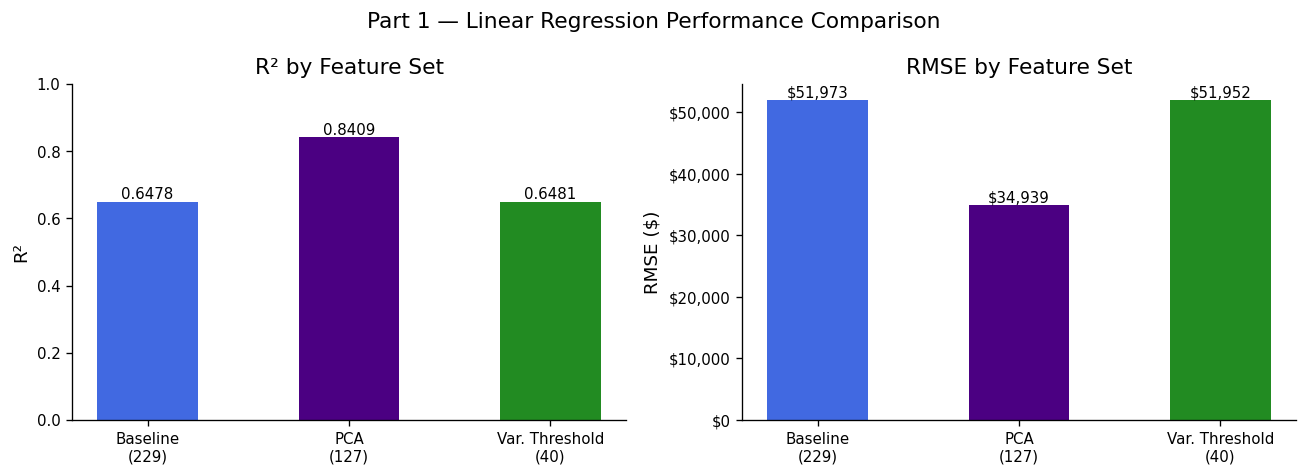

In [45]:
# Compare all three models
results = pd.DataFrame({
    'Model': ['Baseline (229)', 'PCA (127)', 'Var. Threshold (40)'],
    'Features': [229, 127, 40],
    'R²': [r2_base, r2_pca, r2_hv],
    'RMSE': [rmse_base, rmse_pca, rmse_hv],
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = [ROYAL_BLUE, PURPLE, FOREST]
labels = ['Baseline\n(229)', 'PCA\n(127)', 'Var. Threshold\n(40)']

axes[0].bar(labels, results['R²'], color=colors, width=0.5)
axes[0].set_title('R² by Feature Set')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results['R²']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(labels, results['RMSE'], color=colors, width=0.5)
axes[1].set_title('RMSE by Feature Set')
axes[1].set_ylabel('RMSE ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(results['RMSE']):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9)

fig.suptitle('Part 1 — Linear Regression Performance Comparison', fontsize=13)
plt.tight_layout()
plt.show()

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

### Part 1 Summary

Three linear regression models were evaluated using different feature selection and
dimensionality reduction strategies on the Ames, Iowa housing dataset.

The **baseline model** used all 229 features after one-hot encoding and achieved an
`R² of 0.6478` and `RMSE of $51,973`, providing a performance benchmark with no
preprocessing beyond imputation and encoding.

The **PCA model** applied standard scaling followed by PCA retaining 90% of variance,
reducing the feature space from 229 to 127 components. This produced the strongest
performance of the three approaches, with an `R² of 0.8409` and `RMSE of $34,939` —
a reduction in error of roughly $17,000 compared to the baseline. The improvement
suggests that the unscaled baseline was sensitive to high-magnitude features dominating
the regression, and that the orthogonal PCA components captured the underlying
structure of the data more effectively.

The **variance threshold model** applied min-max scaling and retained only the 40
features with variance above 0.1, dropping 189 low-variance columns. Despite using
just 17% of the original features, it achieved an `R² of 0.6481` and `RMSE of $51,952` —
nearly identical to the baseline. This indicates that the 40 retained features carried
essentially the same predictive signal as the full feature set, and that the majority
of dropped features contributed little to explaining sale price variation.

</div>

## Part 2 — Categorical Feature Selection (Mushroom Classification)

In [46]:
# ── Exercise 1: Inspect the mushroom dataframe ─────────────────────────────
inspect_dataframe(mushroom_df, 'Mushroom (mushrooms.csv)')
mushroom_df.head(3)

📋 Mushroom (mushrooms.csv)
   Shape            : 8,124 rows × 23 columns
   Numeric columns  : 0
   Categorical cols : 23
   Total missing    : 0


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m


In [47]:
# One-hot encode all categorical columns including target
y_mush = (mushroom_df['class'] == 'p').astype(int)
X_mush = mushroom_df.drop(columns=['class'])
X_mush = pd.get_dummies(X_mush, drop_first=True)

print(f'🔢 Encoding complete')
print(f'   Original columns  : {mushroom_df.shape[1] - 1} features + 1 target')
print(f'   Encoded features  : {X_mush.shape[1]}')
print(f'   Target distribution:')
print(f'     Edible    (0) : {(y_mush == 0).sum():,}')
print(f'     Poisonous (1) : {(y_mush == 1).sum():,}')

🔢 Encoding complete
   Original columns  : 22 features + 1 target
   Encoded features  : 95
   Target distribution:
     Edible    (0) : 4,208
     Poisonous (1) : 3,916


In [48]:
# Split mushroom data into train and test sets
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mush, y_mush, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f'✂️  Target  : class (0 = edible, 1 = poisonous)')
print(f'   Xm_train : {Xm_train.shape}')
print(f'   Xm_test  : {Xm_test.shape}')
print(f'   ym_train : {ym_train.shape}')
print(f'   ym_test  : {ym_test.shape}')

✂️  Target  : class (0 = edible, 1 = poisonous)
   Xm_train : (6499, 95)
   Xm_test  : (1625, 95)
   ym_train : (6499,)
   ym_test  : (1625,)


🌲 Decision Tree — Full Feature Set (95 features)
   Accuracy : 1.0000 (100.00%)


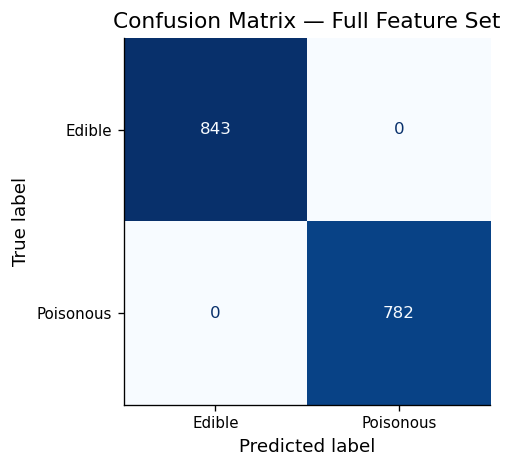

In [49]:
# Fit decision tree and report accuracy + confusion matrix
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(Xm_train, ym_train)

ym_pred_full = tree_full.predict(Xm_test)
acc_full = accuracy_score(ym_test, ym_pred_full)
cm_full = confusion_matrix(ym_test, ym_pred_full)

print(f'🌲 Decision Tree — Full Feature Set (95 features)')
print(f'   Accuracy : {acc_full:.4f} ({acc_full*100:.2f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_full, display_labels=['Edible', 'Poisonous'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Full Feature Set')
plt.tight_layout()
plt.show()

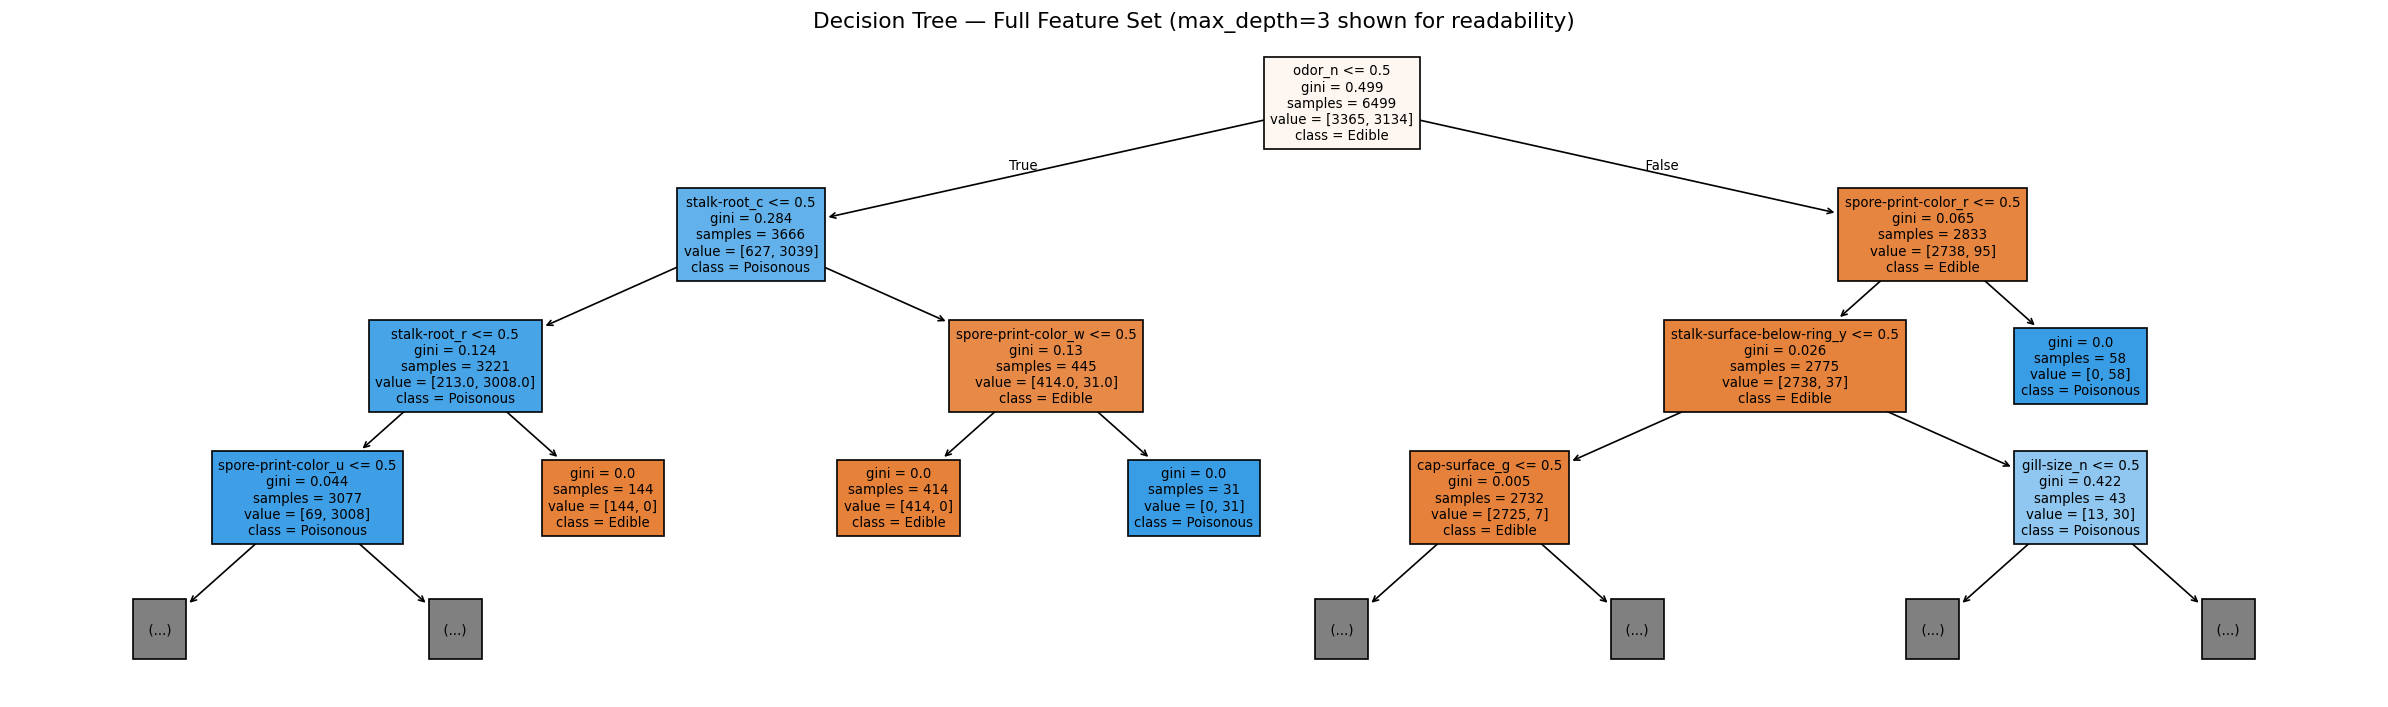

ℹ️  Full tree was trained without a depth limit.


In [50]:
# Visualize the decision tree
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(
    tree_full,
    feature_names=X_mush.columns.tolist(),
    class_names=['Edible', 'Poisonous'],
    max_depth=3,
    filled=True,
    impurity=True,
    ax=ax,
    fontsize=8,
)
ax.set_title(
    'Decision Tree — Full Feature Set (max_depth=3 shown for readability)',
    fontsize=13)
plt.tight_layout()
plt.show()
print('ℹ️  Full tree was trained without a depth limit.')

In [51]:
# Select 5 best features via chi-square statistic
selector = SelectKBest(score_func=chi2, k=5)
Xm_train_sel = selector.fit_transform(
    Xm_train, ym_train)  # fit + transform on train only
# transform only — do NOT fit
Xm_test_sel = selector.transform(Xm_test)

selected_features = X_mush.columns[selector.get_support()].tolist()

print(f'✅ Top 5 features selected by χ² statistic:')
for i, feat in enumerate(selected_features, 1):
    print(f'   {i}. {feat}')
print(f'\n   Xm_train_sel shape : {Xm_train_sel.shape}')
print(f'   Xm_test_sel shape  : {Xm_test_sel.shape}')

✅ Top 5 features selected by χ² statistic:
   1. odor_f
   2. odor_n
   3. gill-size_n
   4. stalk-surface-above-ring_k
   5. stalk-surface-below-ring_k

   Xm_train_sel shape : (6499, 5)
   Xm_test_sel shape  : (1625, 5)


🌲 Decision Tree — Top-5 Chi-Square Features
   Accuracy : 0.9735 (97.35%)


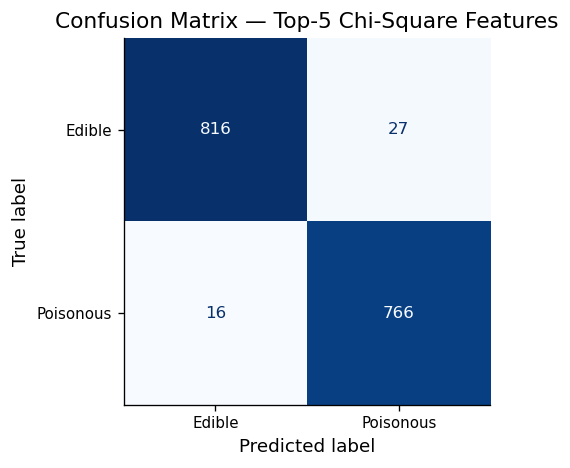

In [52]:
# Fit decision tree on chi-square selected features
tree_sel = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_sel.fit(Xm_train_sel, ym_train)

ym_pred_sel = tree_sel.predict(Xm_test_sel)
acc_sel = accuracy_score(ym_test, ym_pred_sel)
cm_sel = confusion_matrix(ym_test, ym_pred_sel)

print(f'🌲 Decision Tree — Top-5 Chi-Square Features')
print(f'   Accuracy : {acc_sel:.4f} ({acc_sel*100:.2f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm_sel, display_labels=['Edible', 'Poisonous'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Top-5 Chi-Square Features')
plt.tight_layout()
plt.show()

<div style="border: 3px solid black; border-radius: 8px; padding: 20px;">

### Part 2 Summary

A decision tree classifier was evaluated on the Mushroom Classification dataset
using two feature sets: the full 95-feature encoded set and a reduced set of 5
features selected via chi-square statistic.

The **full feature model** achieved perfect accuracy of 100% on the test set,
correctly classifying all 1,625 observations. The decision tree visualization
revealed that `odor_n` served as the root split, suggesting odor alone carries
substantial discriminative power in separating edible from poisonous mushrooms.

The **chi-square selected model** retained only 5 features — `odor_f`, `odor_n`,
`gill-size_n`, `stalk-surface-above-ring_k`, and `stalk-surface-below-ring_k` —
and achieved an accuracy of 97.35%, misclassifying 43 of 1,625 observations.
Of those errors, 16 were false negatives where poisonous mushrooms were predicted
as edible, which represents the more consequential error type in this domain.
The presence of two odor-related features among the top 5 is consistent with the
full tree's root split on `odor_n`, confirming that odor is the strongest predictor
of toxicity in this dataset.

Overall, chi-square feature selection reduced the feature space by 95% with only
a modest loss in accuracy, demonstrating that a small subset of highly associated
features can retain the majority of predictive signal in categorical classification tasks.

</div>

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

# Week 7 Reflection 

## Overall Reflection

Week 7 brought together several important concepts in preprocessing, dimensionality reduction, and categorical feature selection. Working through both the housing regression task and the mushroom classification task helped reinforce how different techniques influence model performance and interpretability. The feedback I received was especially helpful in sharpening my understanding of preprocessing decisions, such as how scaling before PCA can influence linear regression results and why certain encoding choices matter when performing feature selection. This week felt like a strong continuation of building full machine learning workflows while also learning to communicate limitations and methodological choices more clearly.

## Straightforward Aspects

### Data Preparation Steps  
Loading the datasets, handling missing values, dropping features with excessive missingness, and converting categorical variables to dummy variables were all familiar processes. These steps followed a logical sequence and made the rest of the workflow smooth.

### Baseline Linear Regression  
Running the initial linear regression and reporting R² and RMSE felt direct. The evaluation metrics behaved as expected, and interpreting the results was clear.

### PCA Transformation  
Fitting PCA to retain 90 percent variance and transforming the test set without refitting was straightforward. Identifying the number of resulting components and repeating the regression with PCA features followed naturally.

### Decision Tree Model  
Training the decision tree classifier, generating accuracy scores, and producing the confusion matrix were all intuitive steps. Even though the visualization was large, creating it was simple and aligned with the instructions.

## Challenging Portions

### Encoding Choices for Feature Selection  
The feedback about avoiding `drop_first=True` for the mushroom dataset highlighted a subtle but important point. While dropping the first category is usually helpful for avoiding multicollinearity, it can unintentionally remove meaningful categories when performing chi square feature selection. This was a good reminder that encoding choices must match the specific analytical goal.

### Communicating Visualization Limitations  
The decision tree visualization was too large to display fully, and although I noted this, the feedback suggested making that limitation more explicit. It reinforced the importance of clearly communicating constraints in both analysis and reporting.

### Understanding Preprocessing Effects  
The reminder that scaling before PCA can influence linear regression results emphasized that preprocessing is not just a routine step but a modeling decision. This pushed me to think more critically about how each transformation affects downstream performance.

### Variance Threshold Interpretation  
Applying the min max scaler and then identifying features with variance above 0.1 required more careful interpretation. Understanding why certain features passed the threshold and how that influenced the regression results took additional reflection.

## Summary

Week 7 strengthened my understanding of how preprocessing, dimensionality reduction, and feature selection shape model behavior. The feedback helped refine both my technical approach and the clarity of my explanations. Overall, this week reinforced the importance of thoughtful preprocessing decisions and clear communication when building and evaluating machine learning models.
